# COVID-19 Pandemic Analysis: GDP Level, Healthcare Response Capacity, and Case Fatality Rate

This notebook investigates the empirical relationship between national economic level (`gdp_per_capita`), vaccine rollout dynamics, diagnostic surveillance disparities, and Case Fatality Rates (CFR) across 80 countries using historical panel data from **Our World in Data (OWID)**.

In [1]:
# ----------------------------------------------------------------------
# [단계 1] 라이브러리 임포트 및 환경 설정 / 데이터 로드
# ----------------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 기본 스타일 설정
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 프로젝트 디렉토리 및 입출력 경로 설정
project_root = os.path.abspath("..") if os.path.basename(os.getcwd()) in ["notebooks", "src"] else os.path.abspath(".")
data_path = os.path.join(project_root, "data", "compact.csv")
fig_dir = os.path.join(project_root, "results", "figures")
tab_dir = os.path.join(project_root, "results", "tables")

os.makedirs(fig_dir, exist_ok=True)
os.makedirs(tab_dir, exist_ok=True)

# 상대 경로를 통한 데이터 파일 탐색 및 예외 처리
if not os.path.exists(data_path):
    fallback_path = os.path.join(project_root, "compact.csv")
    if os.path.exists(fallback_path):
        data_path = fallback_path
    else:
        raise FileNotFoundError(
            f"Dataset not found at '{data_path}'.\n"
            "Please obtain the Our World in Data (OWID) COVID-19 dataset ('compact.csv') "
            "and place it in the 'data/' directory before running this notebook."
        )

print(f"Loading dataset from: {data_path}")
raw_df = pd.read_csv(data_path)

# OWID 컬럼 호환성 처리 (location -> country)
if 'location' in raw_df.columns and 'country' not in raw_df.columns:
    raw_df = raw_df.rename(columns={'location': 'country'})

print(f"Total raw observations loaded: {len(raw_df):,} rows")

Total raw observations loaded: 429,435 rows


In [2]:
# ----------------------------------------------------------------------
# [단계 2 & 3] 분석용 데이터프레임 생성 및 GDP 기준 그룹 정의
# ----------------------------------------------------------------------
# 2a. 핵심 분석 변수 정의
essential_columns = [
    'country',
    'date',
    'gdp_per_capita',                       # 그룹 분류 기준
    'new_cases_per_million',                # 신규 확진자 지표
    'total_deaths_per_million',             # 누적 사망률 지표
    'total_cases',                          # CFR 계산용 분모
    'total_deaths',                         # CFR 계산용 분자
    'people_fully_vaccinated_per_hundred',  # 백신 접종 완료율
    'new_vaccinations_smoothed_per_million' # 일일 접종 속도
]

# 2b. 핵심 컬럼 선택
analysis_df = raw_df[essential_columns].copy()

# 3a. 국가별 고유 GDP 값 추출 (날짜 중복 제거)
country_gdp = analysis_df.groupby('country')['gdp_per_capita'].max()

# 3b. 상/하위 20% 경계값(Quantile) 계산
q_low = country_gdp.quantile(0.2)
q_high = country_gdp.quantile(0.8)

print(f"--- GDP 그룹 경계값 (20% / 80% Quantile) ---")
print(f"하위 20% (Low) GDP 기준 : ${q_low:,.2f} 이하")
print(f"상위 20% (High) GDP 기준: ${q_high:,.2f} 이상")

# 3c. 경계값에 해당하는 국가 리스트 추출
low_gdp_countries = country_gdp[country_gdp <= q_low].index
high_gdp_countries = country_gdp[country_gdp >= q_high].index

print(f"Low GDP 그룹 국가 수 : {len(low_gdp_countries)}개")
print(f"High GDP 그룹 국가 수: {len(high_gdp_countries)}개")

# 그룹별 데이터프레임 생성
gdp_low_df = analysis_df[analysis_df['country'].isin(low_gdp_countries)].copy()
gdp_high_df = analysis_df[analysis_df['country'].isin(high_gdp_countries)].copy()

--- GDP 그룹 경계값 (20% / 80% Quantile) ---
하위 20% (Low) GDP 기준 : $3,364.93 이하
상위 20% (High) GDP 기준: $33,132.32 이상
Low GDP 그룹 국가 수 : 40개
High GDP 그룹 국가 수: 40개


In [3]:
# ----------------------------------------------------------------------
# [단계 4] 'gdp_group' 컬럼 추가 및 상/하위 20% 코호트 필터링
# ----------------------------------------------------------------------
# 4a. gdp_group 기본값 설정
analysis_df['gdp_group'] = 'Other'

# 4b. Low 및 High 그룹 할당
analysis_df.loc[analysis_df['country'].isin(low_gdp_countries), 'gdp_group'] = 'Low'
analysis_df.loc[analysis_df['country'].isin(high_gdp_countries), 'gdp_group'] = 'High'

# 4c. 중간 60% ('Other') 제외 후 필터링
analysis_df = analysis_df[analysis_df['gdp_group'] != 'Other'].copy()

print("--- 'gdp_group' 생성 및 코호트 필터링 완료 ---")
print(analysis_df['gdp_group'].value_counts())

--- 'gdp_group' 생성 및 코호트 필터링 완료 ---
gdp_group
Low     66960
High    66071
Name: count, dtype: int64


In [4]:
# ----------------------------------------------------------------------
# [단계 4.5] 핵심 지표 결측치 정제
# ----------------------------------------------------------------------
# total_cases와 total_deaths가 결측된 초기 행 제거
initial_rows = len(analysis_df)
analysis_df = analysis_df.dropna(subset=['total_cases', 'total_deaths']).copy()
final_rows = len(analysis_df)

print(f"--- 결측치 정제 완료 ---")
print(f"총 {initial_rows:,}개 행 중 유효 관측치 {final_rows:,}개 행 유지 (제거: {initial_rows - final_rows:,}개 행)")

--- 결측치 정제 완료 ---
총 133,031개 행 중 유효 관측치 130,572개 행 유지 (제거: 2,459개 행)


In [5]:
# ----------------------------------------------------------------------
# [단계 5] GDP 그룹별 백신 접종 역량 비교
# ----------------------------------------------------------------------
# 그룹별 백신 접종 완료율 및 일일 접종 속도 평균 계산
vaccine_analysis_df = analysis_df.groupby('gdp_group')[[
    'people_fully_vaccinated_per_hundred',
    'new_vaccinations_smoothed_per_million'
]]

vaccine_mean = vaccine_analysis_df.mean()

print("--- [가설 1] GDP 그룹별 백신 접종률 및 일일 접종 속도 평균 ---")
print(vaccine_mean)

--- [가설 1] GDP 그룹별 백신 접종률 및 일일 접종 속도 평균 ---
           people_fully_vaccinated_per_hundred  \
gdp_group                                        
High                                 61.595368   
Low                                  14.453290   

           new_vaccinations_smoothed_per_million  
gdp_group                                         
High                                 2578.395062  
Low                                   821.191997  


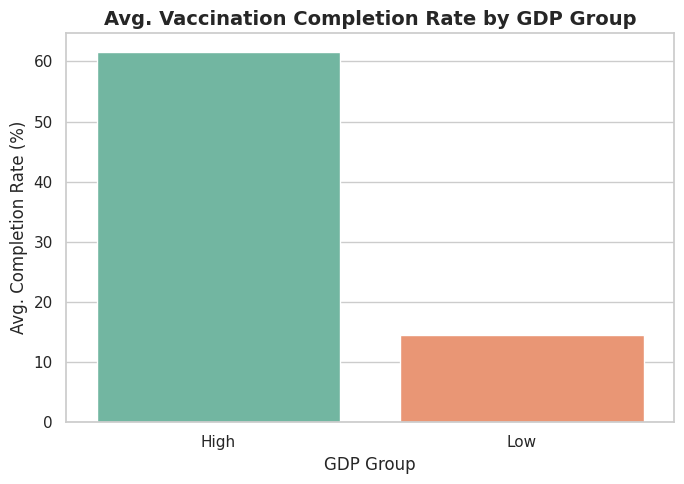

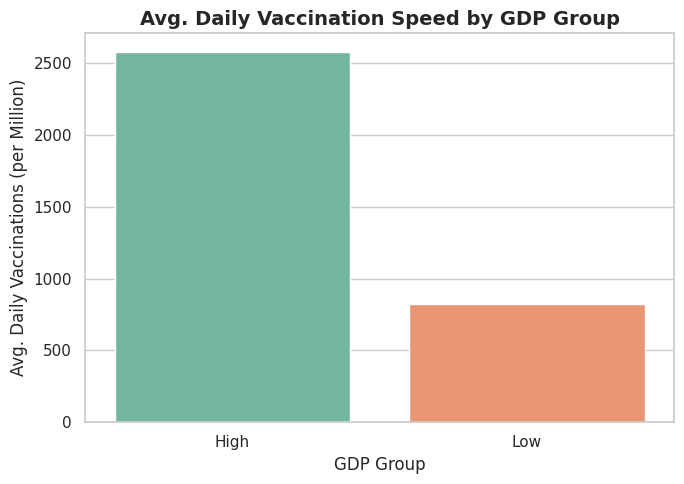

In [6]:
# ----------------------------------------------------------------------
# [단계 5.5] 백신 접종 완료율 및 일일 접종 속도 시각화
# ----------------------------------------------------------------------
plot_data = vaccine_mean.reset_index()

# --- [그래프 1] 평균 백신 접종 완료율 ---
plt.figure(figsize=(7, 5))
sns.barplot(
    data=plot_data,
    x='gdp_group',
    y='people_fully_vaccinated_per_hundred',
    order=['High', 'Low'],
    hue='gdp_group',
    legend=False,
    palette='Set2'
)
plt.title('Avg. Vaccination Completion Rate by GDP Group', fontsize=14, fontweight='bold')
plt.xlabel('GDP Group', fontsize=12)
plt.ylabel('Avg. Completion Rate (%)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "01_avg_vaccination_completion_rate.png"), dpi=300)
plt.show()

# --- [그래프 2] 평균 일일 접종 속도 ---
plt.figure(figsize=(7, 5))
sns.barplot(
    data=plot_data,
    x='gdp_group',
    y='new_vaccinations_smoothed_per_million',
    order=['High', 'Low'],
    hue='gdp_group',
    legend=False,
    palette='Set2'
)
plt.title('Avg. Daily Vaccination Speed by GDP Group', fontsize=14, fontweight='bold')
plt.xlabel('GDP Group', fontsize=12)
plt.ylabel('Avg. Daily Vaccinations (per Million)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "02_avg_daily_vaccination_speed.png"), dpi=300)
plt.show()

In [7]:
# ----------------------------------------------------------------------
# [단계 6] 신규 확진자 및 누적 사망률 지표 분석 (통계적 역설 탐색)
# ----------------------------------------------------------------------
# 그룹별 일일 신규 확진자 평균 및 누적 사망률 최대값 계산
avg_new_cases = analysis_df.groupby('gdp_group')['new_cases_per_million'].mean()
max_total_deaths = analysis_df.groupby('gdp_group')['total_deaths_per_million'].max()

print("--- [가설 2] 신규 확진자 (일일 평균, per Million) ---")
print(avg_new_cases)

print("\n--- [가설 2] 누적 사망률 (최대값, per Million) ---")
print(max_total_deaths)

--- [가설 2] 신규 확진자 (일일 평균, per Million) ---
gdp_group
High    242.871237
Low       9.126445
Name: new_cases_per_million, dtype: float64

--- [가설 2] 누적 사망률 (최대값, per Million) ---
gdp_group
High    3693.61
Low      579.72
Name: total_deaths_per_million, dtype: float64


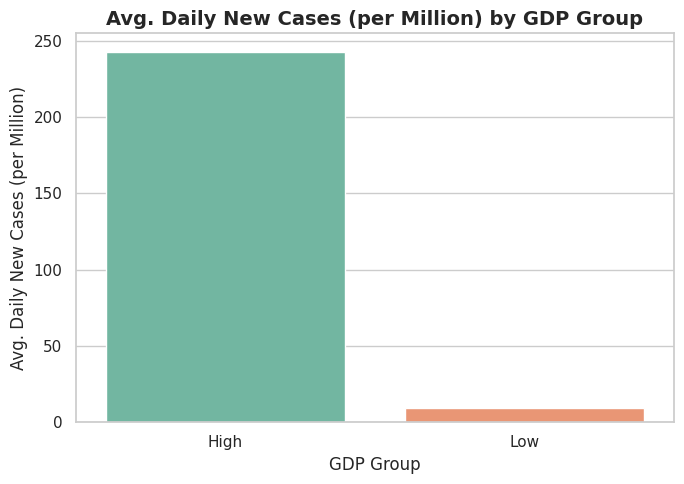

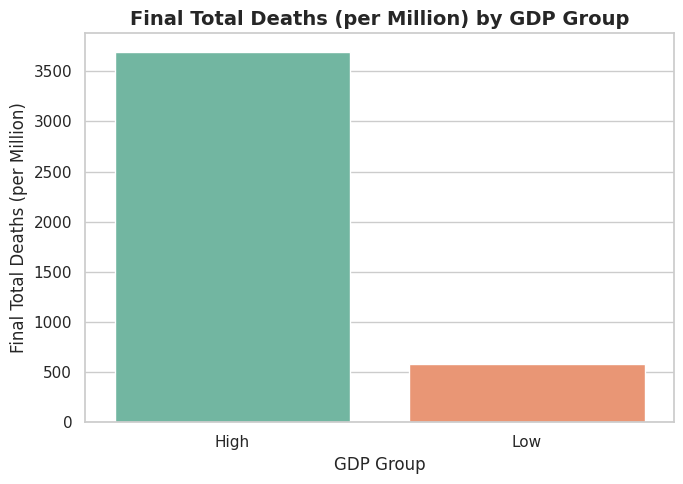

In [8]:
# ----------------------------------------------------------------------
# [단계 6.5] 신규 확진자 및 누적 사망률 시각화
# ----------------------------------------------------------------------
plot_data_cases = avg_new_cases.reset_index()
plot_data_deaths = max_total_deaths.reset_index()

# --- [그래프 3] 신규 확진자 (일일 평균) ---
plt.figure(figsize=(7, 5))
sns.barplot(
    data=plot_data_cases,
    x='gdp_group',
    y='new_cases_per_million',
    order=['High', 'Low'],
    hue='gdp_group',
    legend=False,
    palette='Set2'
)
plt.title('Avg. Daily New Cases (per Million) by GDP Group', fontsize=14, fontweight='bold')
plt.xlabel('GDP Group', fontsize=12)
plt.ylabel('Avg. Daily New Cases (per Million)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "03_avg_daily_new_cases.png"), dpi=300)
plt.show()

# --- [그래프 4] 누적 사망률 (최종 최대값) ---
plt.figure(figsize=(7, 5))
sns.barplot(
    data=plot_data_deaths,
    x='gdp_group',
    y='total_deaths_per_million',
    order=['High', 'Low'],
    hue='gdp_group',
    legend=False,
    palette='Set2'
)
plt.title('Final Total Deaths (per Million) by GDP Group', fontsize=14, fontweight='bold')
plt.xlabel('GDP Group', fontsize=12)
plt.ylabel('Final Total Deaths (per Million)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "04_final_total_deaths.png"), dpi=300)
plt.show()

In [9]:
# ----------------------------------------------------------------------
# [단계 7] 검사 총량 데이터 신뢰도 및 결측률 분석 (검출 편향 진단)
# ----------------------------------------------------------------------
# 검사 총량 데이터 추출 및 GDP 그룹 매핑
test_df = raw_df[['country', 'new_tests_per_thousand']].copy()
test_df['gdp_group'] = 'Other'
test_df.loc[test_df['country'].isin(low_gdp_countries), 'gdp_group'] = 'Low'
test_df.loc[test_df['country'].isin(high_gdp_countries), 'gdp_group'] = 'High'
test_df = test_df[test_df['gdp_group'].isin(['High', 'Low'])]

test_analysis = test_df.groupby('gdp_group')['new_tests_per_thousand']

# 그룹별 일일 검사량 평균 및 결측치 비율(%)
test_mean = test_analysis.mean()
test_nan_percent = test_analysis.apply(lambda x: x.isna().mean()) * 100

print("--- 검사 총량 그룹별 비교 결과 ---")
print("\n그룹별 일일 검사량 평균 (per Thousand):")
print(test_mean)

print("\n그룹별 검사 데이터 결측률 (%):")
print(test_nan_percent)

test_ratio = test_mean.get('High', 0) / test_mean.get('Low', 1)
low_nan_val = test_nan_percent.get('Low', 0)

print("\n--- 검출 편향 및 데이터 결측 진단 ---")
print(f"1. High 그룹의 보고된 평균 검사량이 Low 그룹보다 약 {test_ratio:.0f}배 높게 나타납니다.")
print(f"2. Low 그룹의 검사 데이터 결측률은 {low_nan_val:.1f}%에 달하여, 확진자 수 직접 비교 시 심각한 감시 편향(Surveillance Bias)이 발생합니다.")
print("3. 따라서 단순 신규 확진자 및 검사량 지표는 국가 간 방역 성과의 비교 지표로서 신뢰성이 제한적입니다.")

--- 검사 총량 그룹별 비교 결과 ---

그룹별 일일 검사량 평균 (per Thousand):
gdp_group
High    5.616580
Low     0.157817
Name: new_tests_per_thousand, dtype: float64

그룹별 검사 데이터 결측률 (%):
gdp_group
High    65.758048
Low     91.181302
Name: new_tests_per_thousand, dtype: float64

--- 검출 편향 및 데이터 결측 진단 ---
1. High 그룹의 보고된 평균 검사량이 Low 그룹보다 약 36배 높게 나타납니다.
2. Low 그룹의 검사 데이터 결측률은 91.2%에 달하여, 확진자 수 직접 비교 시 심각한 감시 편향(Surveillance Bias)이 발생합니다.
3. 따라서 단순 신규 확진자 및 검사량 지표는 국가 간 방역 성과의 비교 지표로서 신뢰성이 제한적입니다.


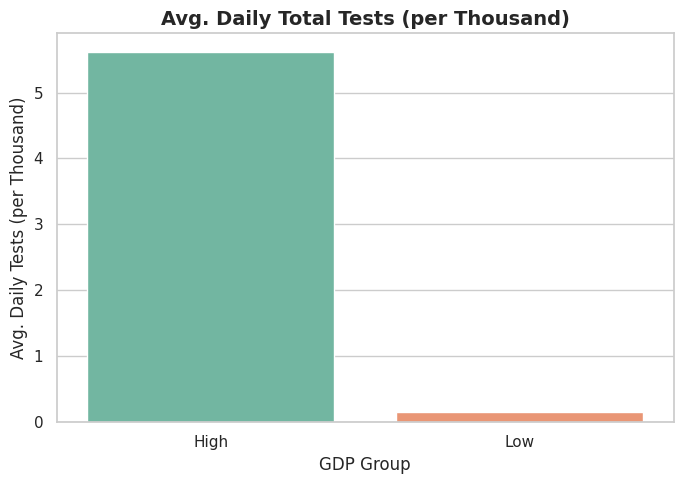

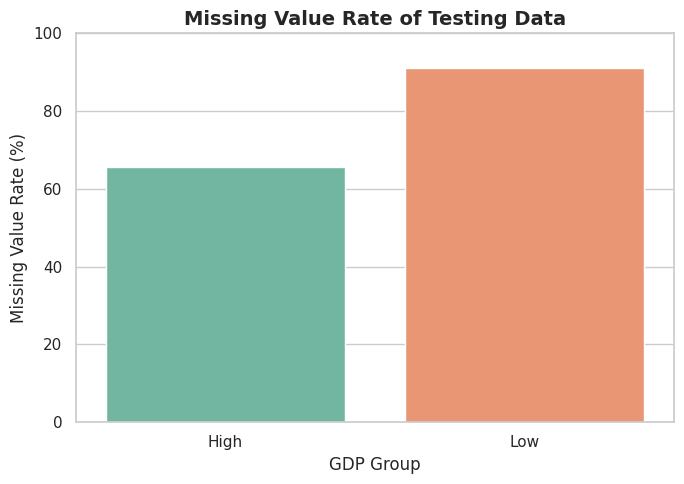

In [10]:
# ----------------------------------------------------------------------
# [단계 7.5] 검사 총량 및 결측률 비교 시각화
# ----------------------------------------------------------------------
plot_data_test = test_mean.reset_index()
plot_data_nan = test_nan_percent.reset_index()

# --- [그래프 5] 총 검사량 (일일 평균) ---
plt.figure(figsize=(7, 5))
sns.barplot(
    data=plot_data_test,
    x='gdp_group',
    y='new_tests_per_thousand',
    order=['High', 'Low'],
    hue='gdp_group',
    legend=False,
    palette='Set2'
)
plt.title('Avg. Daily Total Tests (per Thousand)', fontsize=14, fontweight='bold')
plt.xlabel('GDP Group', fontsize=12)
plt.ylabel('Avg. Daily Tests (per Thousand)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "05_avg_daily_tests.png"), dpi=300)
plt.show()

# --- [그래프 6] 검사 데이터 결측치 비율 ---
plt.figure(figsize=(7, 5))
sns.barplot(
    data=plot_data_nan,
    x='gdp_group',
    y='new_tests_per_thousand',
    order=['High', 'Low'],
    hue='gdp_group',
    legend=False,
    palette='Set2'
)
plt.title('Missing Value Rate of Testing Data', fontsize=14, fontweight='bold')
plt.xlabel('GDP Group', fontsize=12)
plt.ylabel('Missing Value Rate (%)', fontsize=12)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "06_missing_rate_testing_data.png"), dpi=300)
plt.show()

In [11]:
# ----------------------------------------------------------------------
# [단계 8] 국가별 최종 Case Fatality Rate (CFR) 계산 및 그룹별 비교
# ----------------------------------------------------------------------
# 8a. 국가별 최종 누적 확진자 및 사망자 기반 CFR 계산
country_final_df = analysis_df.groupby('country')[['total_cases', 'total_deaths']].max().fillna(0)
country_final_df = country_final_df[country_final_df['total_cases'] > 0]

# CFR 연산 (CFR = total_deaths / total_cases * 100)
country_final_df['CFR'] = (country_final_df['total_deaths'] / country_final_df['total_cases']) * 100

# 8b. GDP 그룹 할당
country_final_df['gdp_group'] = 'Other'
country_final_df.loc[country_final_df.index.isin(low_gdp_countries), 'gdp_group'] = 'Low'
country_final_df.loc[country_final_df.index.isin(high_gdp_countries), 'gdp_group'] = 'High'

cfr_analysis_df = country_final_df[country_final_df['gdp_group'].isin(['High', 'Low'])].copy()

# 그룹별 평균 CFR
avg_cfr = cfr_analysis_df.groupby('gdp_group')['CFR'].mean()

print("--- GDP 그룹별 평균 치사율 (Case Fatality Rate, CFR) (%) ---")
print(avg_cfr)

print(f"\n[분석 결과] Low GDP 그룹의 평균 CFR ({avg_cfr['Low']:.2f}%)은 High GDP 그룹 ({avg_cfr['High']:.2f}%) 대비 약 {avg_cfr['Low']/avg_cfr['High']:.1f}배 높게 나타납니다.")
print("이는 의료 자원 및 백신 보급 격차가 중증 환자 생존 관리에 미친 차이를 시사합니다.")

# 국가별 CFR 결과 테이블 저장
cfr_analysis_df.to_csv(os.path.join(tab_dir, "cfr_by_country.csv"))

--- GDP 그룹별 평균 치사율 (Case Fatality Rate, CFR) (%) ---
gdp_group
High    0.506816
Low     2.006889
Name: CFR, dtype: float64

[분석 결과] Low GDP 그룹의 평균 CFR (2.01%)은 High GDP 그룹 (0.51%) 대비 약 4.0배 높게 나타납니다.
이는 의료 자원 및 백신 보급 격차가 중증 환자 생존 관리에 미친 차이를 시사합니다.


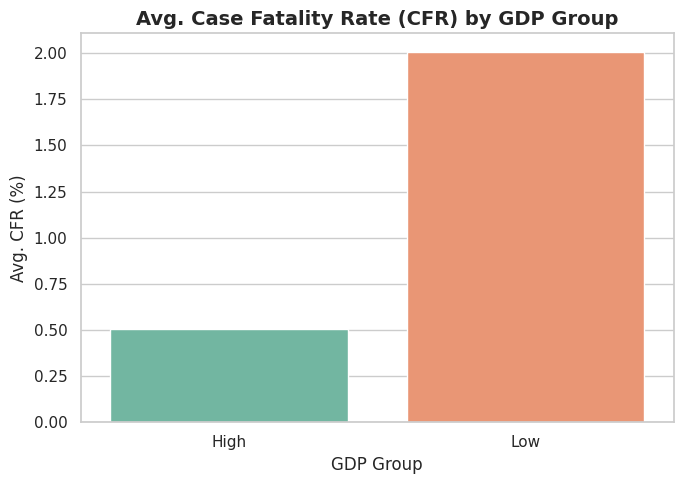

In [12]:
# ----------------------------------------------------------------------
# [단계 8.5] GDP 그룹별 평균 CFR 시각화
# ----------------------------------------------------------------------
plot_data_cfr = avg_cfr.reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(
    data=plot_data_cfr,
    x='gdp_group',
    y='CFR',
    order=['High', 'Low'],
    hue='gdp_group',
    legend=False,
    palette='Set2'
)
plt.title('Avg. Case Fatality Rate (CFR) by GDP Group', fontsize=14, fontweight='bold')
plt.xlabel('GDP Group', fontsize=12)
plt.ylabel('Avg. CFR (%)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "07_avg_case_fatality_rate.png"), dpi=300)
plt.show()

In [13]:
# ----------------------------------------------------------------------
# [단계 9] 대체 의료 인프라 지표 결측률 분석 (CFR 지표 타당성 검증)
# ----------------------------------------------------------------------
total_rows = len(raw_df)

columns_to_check = [
    'total_cases',
    'total_deaths',
    'new_tests_per_thousand',
    'hospital_beds_per_thousand',
    'icu_patients_per_million',
    'hosp_patients_per_million'
]

nan_results = {}
print("--- 의료 인프라 및 핵심 지표 결측치 비율 비교 ---")
for col in columns_to_check:
    nan_count = raw_df[col].isna().sum()
    nan_percentage = (nan_count / total_rows) * 100
    nan_results[col] = nan_percentage
    print(f"{col:<30}: {nan_percentage:6.2f}% (NaN)")

total_cases_nan = nan_results['total_cases']
b_group_cols = ['new_tests_per_thousand', 'hospital_beds_per_thousand', 'icu_patients_per_million', 'hosp_patients_per_million']
min_nan = min(nan_results[col] for col in b_group_cols)
max_nan = max(nan_results[col] for col in b_group_cols)

print("\n--- CFR 지표 채택 타당성 ---")
print(f"1. CFR 산출의 기반인 'total_cases'와 'total_deaths'의 결측률은 {total_cases_nan:.2f}%로 매우 낮아 데이터 완결성이 우수합니다.")
print(f"2. 반면 병상/중환자실 등 직접적 의료 인프라 지표는 결측률이 {min_nan:.2f}% ~ {max_nan:.2f}%에 달하여 글로벌 비교 분석에 한계가 존재합니다.")

--- 의료 인프라 및 핵심 지표 결측치 비율 비교 ---
total_cases                   :   4.11% (NaN)
total_deaths                  :   4.11% (NaN)
new_tests_per_thousand        :  82.44% (NaN)
hospital_beds_per_thousand    :  32.31% (NaN)
icu_patients_per_million      :  90.89% (NaN)
hosp_patients_per_million     :  90.53% (NaN)

--- CFR 지표 채택 타당성 ---
1. CFR 산출의 기반인 'total_cases'와 'total_deaths'의 결측률은 4.11%로 매우 낮아 데이터 완결성이 우수합니다.
2. 반면 병상/중환자실 등 직접적 의료 인프라 지표는 결측률이 32.31% ~ 90.89%에 달하여 글로벌 비교 분석에 한계가 존재합니다.


## 종합 지표 요약, 분포 분석 및 시계열 추이 시각화

In [14]:
# ----------------------------------------------------------------------
# [단계 10] 최종 핵심 지표 요약 테이블 생성 및 저장
# ----------------------------------------------------------------------
analysis_df['date'] = pd.to_datetime(analysis_df['date'])

# 요약 테이블 병합
summary_table = vaccine_mean.copy()
summary_table = pd.merge(summary_table, avg_new_cases.to_frame(name='avg_new_cases_per_million'), left_index=True, right_index=True)
summary_table = pd.merge(summary_table, max_total_deaths.to_frame(name='total_deaths_per_million'), left_index=True, right_index=True)
summary_table = pd.merge(summary_table, avg_cfr.to_frame(name='CFR_mean'), left_index=True, right_index=True)

# 요약 테이블 CSV 내보내기
summary_table.to_csv(os.path.join(tab_dir, "summary_table.csv"))

print("--- 최종 핵심 지표 요약 테이블 ---")
summary_table

--- 최종 핵심 지표 요약 테이블 ---


,people_fully_vaccinated_per_hundred,new_vaccinations_smoothed_per_million,avg_new_cases_per_million,total_deaths_per_million,CFR_mean
gdp_group,,,,,
High,61.595368,2578.395062,242.871237,3693.61,0.506816
Low,14.453290,821.191997,9.126445,579.72,2.006889


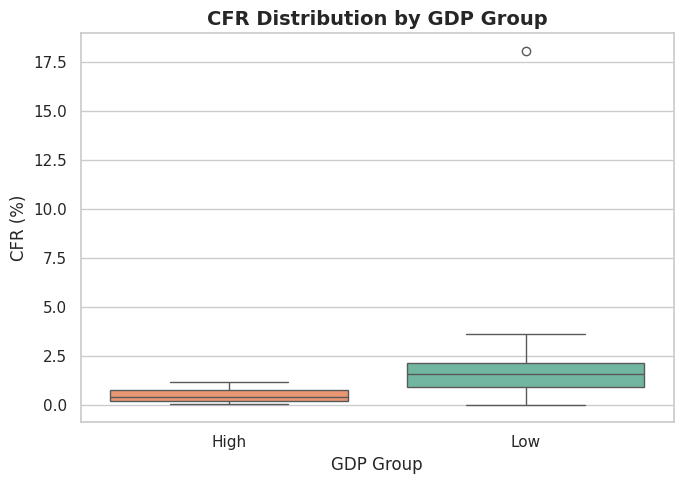

In [15]:
# ----------------------------------------------------------------------
# [단계 11] GDP 그룹별 CFR 분포도 (Box Plot)
# ----------------------------------------------------------------------
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=cfr_analysis_df,
    x='gdp_group',
    y='CFR',
    order=['High', 'Low'],
    hue='gdp_group',
    legend=False,
    palette='Set2'
)
plt.title('CFR Distribution by GDP Group', fontsize=14, fontweight='bold')
plt.xlabel('GDP Group', fontsize=12)
plt.ylabel('CFR (%)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "08_cfr_distribution_boxplot.png"), dpi=300)
plt.show()

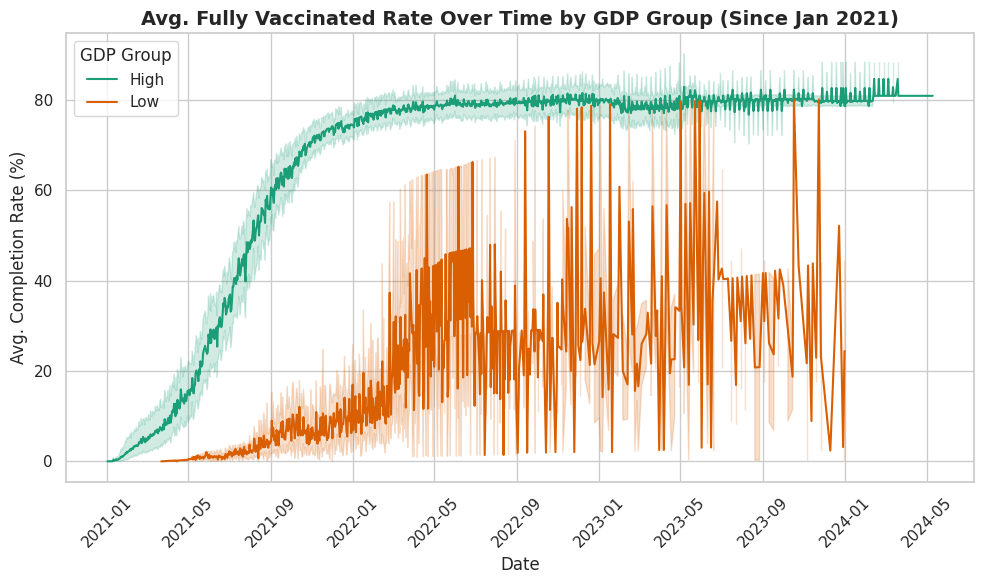

In [16]:
# ----------------------------------------------------------------------
# [단계 12] 백신 접종 완료율 시계열 추이 분석 (Line Plot, 2021년 이후)
# ----------------------------------------------------------------------
df_filtered = analysis_df[analysis_df['date'] >= '2021-01-01'].copy()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_filtered,
    x='date',
    y='people_fully_vaccinated_per_hundred',
    hue='gdp_group',
    palette='Dark2',
    hue_order=['High', 'Low']
)
plt.title('Avg. Fully Vaccinated Rate Over Time by GDP Group (Since Jan 2021)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Avg. Completion Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='GDP Group', loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "09_longitudinal_vaccination_trajectory.png"), dpi=300)
plt.show()